In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
from pathlib import Path
import joblib 


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


190290


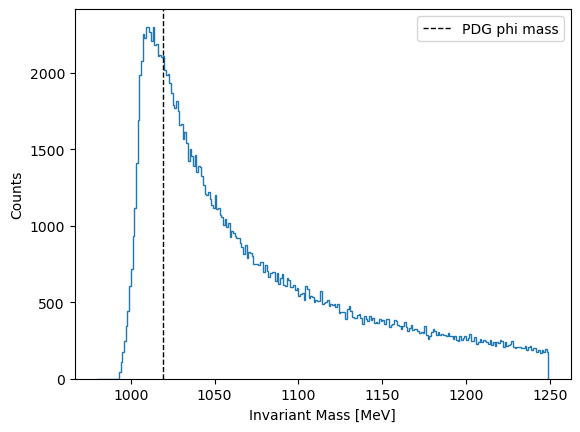

In [22]:
# Non-ML

data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_preds_6/'
selection1 = 0.8
selection2 = 0.995


InvMs = np.array([])

for p in Path(data_dir).iterdir():

    # Load dataframe
    df_data = pd.read_pickle(data_dir+p.name)

    df_data["M"]=mytools.get_InvM(df_data)
    df_data["e_Ptot"] = np.sqrt(df_data.ele_Px**2 + df_data.ele_Py**2 + df_data.ele_Pz**2)
    df_data["p_Ptot"] = np.sqrt(df_data.pos_Px**2 + df_data.pos_Py**2 + df_data.pos_Pz**2)
    df_data['cos_theta'] = (df_data.ele_Px*df_data.pos_Px+df_data.ele_Py*df_data.pos_Py+df_data.ele_Pz*df_data.pos_Pz)/(df_data.e_Ptot*df_data.p_Ptot)

    # Make selections
    df_data = df_data.loc[ ((df_data.p_Ptot-df_data.pos_E_Ecal) > selection1 ) ].reset_index(drop=True)
    df_data = df_data.loc[ ( df_data['cos_theta'] < selection2 ) ].reset_index(drop=True)    

    # Calculate invariant mass
    InvMs = np.concatenate((InvMs,df_data.M))



print(len(InvMs))

plt.hist(1000*InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

588789


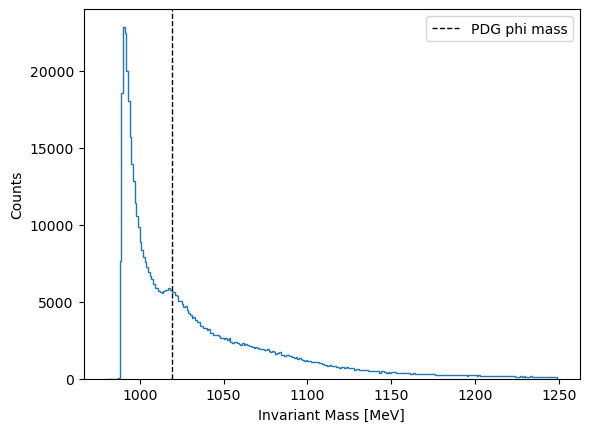

In [73]:
# ANN 1

data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_preds_2/'


ann_selection = 0.74
ann_InvMs = np.array([])



for p in Path(data_dir).iterdir():

    # Load dataframe
    df = pd.read_pickle(data_dir+p.name)

    # Add positron cluster energy filter
    df = df.loc[df.pos_E_Ecal > 0.6]

    # Make selections
    df_ann = df.loc[df.ANN_pred > ann_selection]

    # Calculate invariant mass
    ann_InvMs = np.concatenate((ann_InvMs,mytools.get_InvM(df_ann)))


print(len(ann_InvMs))

plt.hist(1000*ann_InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



398034


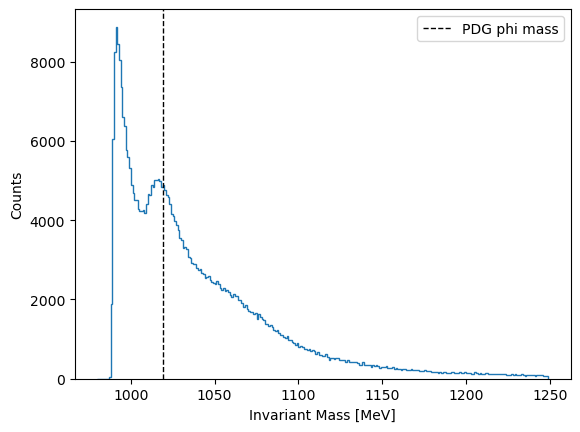

In [50]:
# ANN2

data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_preds/'


ann_selection = 0.781
ann_InvMs = np.array([])

for p in Path(data_dir).iterdir():

    # Load dataframe
    df = pd.read_pickle(data_dir+p.name)

    # Add positron cluster energy filter
    df = df.loc[df.pos_E_Ecal > 0.6]

    # Make selections
    df_ann = df.loc[df.ANN_pred > ann_selection]

    # Calculate invariant mass
    ann_InvMs = np.concatenate((ann_InvMs,mytools.get_InvM(df_ann)))


print(len(ann_InvMs))

plt.hist(1000*ann_InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



23556


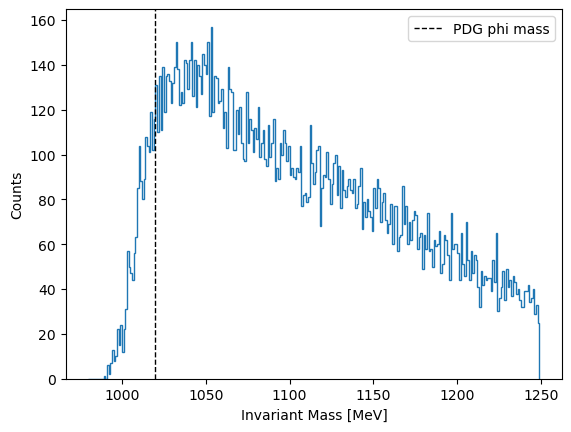

In [57]:
# ANN3

data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_preds_4/'


ann_selection = 0.999
ann_InvMs = np.array([])

for p in Path(data_dir).iterdir():

    # Load dataframe
    df = pd.read_pickle(data_dir+p.name)

    # Add positron cluster energy filter
    df = df.loc[df.pos_E_Ecal > 0.6]

    # Make selections
    df_ann = df.loc[df.ANN_pred > ann_selection]

    # Calculate invariant mass
    ann_InvMs = np.concatenate((ann_InvMs,mytools.get_InvM(df_ann)))


print(len(ann_InvMs))

plt.hist(1000*ann_InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



In [ ]:
#BDT

data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_preds/'


bdt_selection = 0.73
bdt_InvMs = np.array([])


for p in Path(data_dir).iterdir():

    # Load dataframe
    df = pd.read_pickle(data_dir+p.name)

    # Add positron cluster energy filter
    df = df.loc[df.pos_E_Ecal > 0.6]

    # Make selections
    df_bdt = df.loc[df.bdt_model_pred > bdt_selection]

    # Calculate invariant mass
    bdt_InvMs = np.concatenate((bdt_InvMs,mytools.get_InvM(df_bdt)))

print(len(bdt_InvMs))


plt.hist(1000*bdt_InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

118771


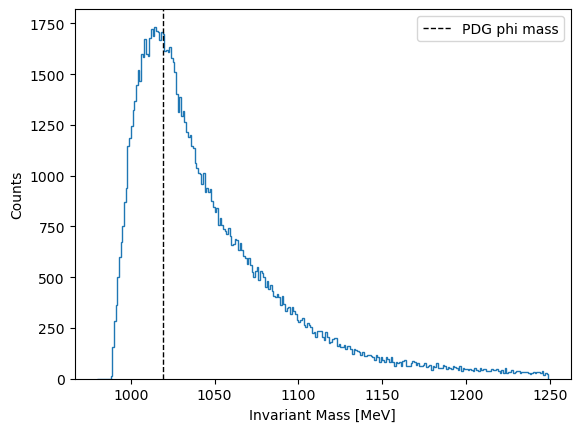

In [72]:
# Full model

data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_preds_11/'


ann_selection = 0.96
ann_InvMs = np.array([])

for p in Path(data_dir).iterdir():

    # Load dataframe
    df = pd.read_pickle(data_dir+p.name)

    # Add positron cluster energy filter
    df = df.loc[df.pos_E_Ecal > 0.6]

    # Make selections
    df_ann = df.loc[df.ANN_pred > ann_selection]

    # Calculate invariant mass
    ann_InvMs = np.concatenate((ann_InvMs,mytools.get_InvM(df_ann)))



print(len(ann_InvMs))

plt.hist(1000*ann_InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()